# Quantum Teleportation
<hr></hr>

Quantum teleportation is a quantum communication protocol that, according to the standard description of quantum mechanics, allows a sender to transmit the **complete** quantum state of a system to a remote party at distant location without physically sending the system itself. As long as the two parties share a pair of entangled qubits ahead of time, an arbitrary quantum state prepared by the sender can be fully recovered by the receiver using only two classical bits of information.

The concept of quantum teleportation was introduced in 1993 by [Charles Bennett](https://en.wikipedia.org/wiki/Charles_H._Bennett_(physicist)), [Gilles Brassard](https://en.wikipedia.org/wiki/Gilles_Brassard), Claude Crépeau, [Richard Jozsa](https://en.wikipedia.org/wiki/Richard_Jozsa), [Asher Peres](https://en.wikipedia.org/wiki/Asher_Peres), and [William Wootters](https://en.wikipedia.org/wiki/William_Wootters) in their paper “*Teleporting an Unknown Quantum State via Dual Classical and Einstein–Podolsky–Rosen Channels*” [[Bennett93](https://link.aps.org/pdf/10.1103/PhysRevLett.70.1895)].

Quantum teleportation has been the subject of considerable debate throughout the years. On one hand, the protocol has been experimentally demonstrated many times, including over extremely long distances [[Ren17](https://arxiv.org/pdf/1707.00934)], [[Valivarthi20](https://arxiv.org/pdf/2007.11157)]. On the other hand, although teleportation does not allow information to be transmitted faster than light, the conventional mathematical description does suggests that the state of a remote system changes instantaneously when an entangled sender performs a measurement. This tension has led to the development of alternative ways of describing quantum teleportation in a way that both locality and realism are respected [[Deutsch99](https://arxiv.org/pdf/quant-ph/9906007)], [[Bédard23](https://www.mdpi.com/2624-960X/5/2/34)]. Exploring these interpretations, however, falls outside the scope of this chapter. Instead, we will work within the standard formalism, while keeping in mind that the physical interpretation of the process may be more subtle than what the equations alone might suggest.

## 1. Transmitting a Quantum State... Classically

Let's start with a hypothetical example where, for reasons we will not worry much about, a scientist named Alice is tasked with performing an important step of a larger experiment. Her role is to run a simulation on a classical computer that spits out two real numbers. Alice must then transmit these values to a second experimenter named Bob, who is longways away. She can do this by using a classical channel like the Internet, a telephone, or even something more rudimentary like a telegraph.

<img src="images/03_02_01_classical_transmit.png" align = "center" width="850"/>

The two numbers to be transmitted represent a pair of angles $(\theta, \varphi)$ that Bob then needs to use to generate a qubit state $|q\rangle$ on his own quantum computer. Alice wants to make sure that Bob gets these two values with some level of precision, so she approximates them as two 16-bit floating-point ([FP16](https://en.wikipedia.org/wiki/Half-precision_floating-point_format)) numbers $(\tilde{\theta}, \tilde{\varphi}).$ For example, if the two angles are:

$$ (\theta, \varphi) = \left(\frac{\pi}{2}, \frac{\pi}{4} \right), $$

then Alice will transmit to Bob the following FP16 binary strings: $( 0011101001001000, 0011111001001000 ),$

which correspond to the following approximate values:

$$ \left(\tilde{\theta}, \tilde{\varphi} \right) \approx (1.570, 0.785). $$

Bob can then program the rotation gates in his quantum computer to construct an approximation of the state of interest:

$$ |\tilde{q}\rangle = \cos\left(\frac{\tilde{\theta}}{2} \right)|0\rangle + e^{i\tilde{\varphi}} \sin\left(\frac{\tilde{\theta}}{2} \right) |1\rangle.$$

To improve the precision of the transmitted angles, Alice can of course increase the number of bits, or use a slightly more efficient bit-encoding scheme. Regardless, Alice must communicate to Bob at least a couple dozen bits of information so he can generate a decent representation of $|q\rangle.$

In contrast, the quantum teleportation protocol allows Alice to transmit to Bob a quantum state using **only two bits**. The caveat is that Alice and Bob must preemptively share an entangled pair of qubits.

## 2. Transmitting a Quantum State... Quantumly

### 2.1 Teleporting Single-Qubit States

The quantum teleportation protocol relies on Alice and Bob first sharing an entangled state such as: 

$$ |\Phi^+\rangle = \frac{1}{\sqrt{2}} \big(|0\rangle_A|0\rangle_B + |1\rangle_A|1\rangle_B \big), $$ 

where the subscripts $A, B$ are used to denote Alice's and Bob's qubits, respectively.

A way to accomplish this is by, for example, having Alice prepare $|\Phi^+\rangle$ on a quantum computer, and then "sending" Bob one of the qubits via a quantum link. Once Bob "receives" his qubit, the link can be broken (provided that both Alice and Bob can store their qubit for later use).

<img src="images/03_02_02_quantum_transmit.png" align = "center" width="675"/>

Similar kinds of entanglement distribution systems have been experimentally verified over the years, including a recent demonstration where two remote ensemble of atoms (420 km apart) were entangled via a photonic link [[Luo25](https://arxiv.org/pdf/2504.05660v1)].

Once Alice and Bob share an entangled pair of qubits, Alice will be able to teleport an arbitrary qubit state $|q\rangle$ to Bob by only sharing with him two classical bits of information. 

Here one might ask: "If Alice has the capability of sending a qubit to Bob, why not send the state of interest $|q\rangle$ in the first place?" The idea here is that in quantum teleportation, the pair of entangled qubits can be established way ahead of time, so that as once Alice has $|q\rangle$ available, she can transfer it to Bob "instantaneously".

To understand the details of how this works, we can use a circuit diagram and analyze the evolution of the shared quantum state each step of the way:

<img src="images/03_02_03_teleportation_circuit.png" align = "center" width="850"/>

0. Alice starts by initializing three of her qubits in the all-zeros state: $|0 0 0\rangle_A.$

1. She then prepares the $|\Phi^+\rangle$ Bell state on two of her qubits:

$$ 
\begin{aligned}
|\psi\rangle_1 &= |0\rangle_A |\Phi^+\rangle_A
\\
\\
|\psi\rangle_1 &= \frac{1}{\sqrt{2}} |0\rangle_A \big(|0\rangle_A|0\rangle_A + |1\rangle_A|1\rangle_A \big). 
\end{aligned}$$

Alice then proceeds to send one of the entangled qubits to Bob. Doing this doesn't change the state itself; we just relabel the subscripts to indicate who has which qubit:

$$ |\psi\rangle_1 = \frac{1}{\sqrt{2}} |0\rangle_A \big(|0\rangle_A|0\rangle_B + |1\rangle_A|1\rangle_B \big). $$

2. With the entangled pair of qubits in place, Alice can then prepare the arbitrary state she plans to teleport to Bob: 

$$|q\rangle = \alpha |0\rangle + \beta |1\rangle.$$ 

As described in the previous section, she could do this by applying the angles $(\theta, \varphi)$ to rotation gates on her quantum computer to set the amplitudes to $\alpha = \cos(\theta/2)$ and $\beta = e^{i\varphi}\sin(\theta/2)$. 

Once Alice prepares $|q\rangle$, The total system is given by:

$$ 
\begin{aligned}
|\psi\rangle_2 &= |q\rangle_A |\Phi^+\rangle_{AB}
\\
\\
|\psi\rangle_2 &= \big(\alpha |0\rangle_A + \beta |1\rangle_A \big) \frac{1}{\sqrt{2}} \big(|0\rangle_A|0\rangle_B + |1\rangle_A|1\rangle_B \big)
\\
\\
|\psi\rangle_2 &= \frac{1}{\sqrt{2}} \big(\alpha |00\rangle_A |0\rangle_B +\alpha |01\rangle_A |1\rangle_B + \beta |10\rangle_A |0\rangle_B + \beta |11\rangle_A |1\rangle_B \big)
\end{aligned}
$$

At this point, we can simply evolve $|\psi\rangle_2$ over the $CX$ and $H$ gates in our circuit to get the final state before measurement. However, it is convenient to rewrite the expression above in a way that allows us to illustrate an interesting aspect of the teleportation protocol:

$$
\begin{aligned}
|\psi\rangle_2 = \frac{1}{2} \bigg[
  & \frac{1}{\sqrt{2}} \big( |00\rangle_A + |11\rangle_A \big) \big(\alpha|0\rangle_B + \beta|1\rangle_B \big) \\
+ & \frac{1}{\sqrt{2}} \big( |01\rangle_A + |10\rangle_A \big) \big(\alpha|1\rangle_B + \beta|0\rangle_B \big) \\
+ & \frac{1}{\sqrt{2}} \big( |00\rangle_A - |11\rangle_A \big) \big(\alpha|0\rangle_B - \beta|1\rangle_B \big) \\
+ & \frac{1}{\sqrt{2}} \big( |01\rangle_A - |10\rangle_A \big) \big(\alpha|1\rangle_B - \beta|0\rangle_B \big) \bigg].
\end{aligned}
$$

It is not hard to show that if we distribute all terms in this equation, some will cancel out, resulting in the same expression we had before. The point of writing $|\psi\rangle_2$ this way is that it allows us to see that Alice's two qubits are actually in a superposition of the four possible [Bell states](https://en.wikipedia.org/wiki/Bell_state):

$$
\begin{aligned}
|\psi\rangle_2 = \frac{1}{2} \big[
  & |\Phi^+\rangle_A \big(\alpha|0\rangle_B + \beta|1\rangle_B \big) \\
+ & |\Psi^+\rangle_A \big(\alpha|1\rangle_B + \beta|0\rangle_B \big) \\
+ & |\Phi^-\rangle_A \big(\alpha|0\rangle_B - \beta|1\rangle_B \big) \\
+ & |\Psi^-\rangle_A \big(\alpha|1\rangle_B - \beta|0\rangle_B \big) \big].
\end{aligned}
$$

Furthermore, Bob's qubit is in one of four possible states that closely resemble $|q\rangle!$ As a matter of fact, these four states only differ from each other by a bit-flip, a phase-flip, or both. This seems to suggest that, if Alice measures her qubits in the Bell basis, Bob will **instantaneously** have in his possession one of these four closely-related states, resulting in the <span style="color:#a883f7">**teleportation**</span> of quantum information from Alice to Bob. 

This, of course, is highly suspicious. How did the transfer happen? Unfortunately, the standard interpretation of quantum mechanics does not provide any satisfying answers, and can even lead to several paradoxes. For instance, the fact that we could rewrite $|\psi\rangle_2$ in a way where Bob already had his qubit in a superposition of possible variations of $|q\rangle$ suggests that Alice's preparation of $|q\rangle$ had a non-local effect on Bob, even though $|q\rangle$ wasn't even entangled with Bob's qubit! One could argue that the expressions above do not really represent anything "physical" but are instead merely mathematical tools to account for the statistics of measurements. This, however, is possibly contradicted by other results in quantum mechanics, like the [PBR theorem](https://en.wikipedia.org/wiki/Pusey%E2%80%93Barrett%E2%80%93Rudolph_theorem). In any case, for practical reasons, we will assume that this non-local effect does indeed happen.

3. Therefore, the next step in the protocol is precisely to apply a $CX$ gate followed by an $H$ gate to convert Alice's qubits from the Bell basis to the computational basis: 

$$
\begin{aligned}
|\psi\rangle_3 = \frac{1}{2} \big[
  & |00\rangle_A \big(\alpha|0\rangle_B + \beta|1\rangle_B \big) \\
+ & |01\rangle_A \big(\alpha|1\rangle_B + \beta|0\rangle_B \big) \\
+ & |10\rangle_A \big(\alpha|0\rangle_B - \beta|1\rangle_B \big) \\
+ & |11\rangle_A \big(\alpha|1\rangle_B - \beta|0\rangle_B \big) \big].
\end{aligned}
$$

4. Then, when Alice measures her qubits, there will be four possible scenarios:

- With probability $1/4,$ Alice measures $00,$ leaving Bob with state: $|\psi\rangle_4 = \alpha|0\rangle_B + \beta|1\rangle_B .$
- With probability $1/4,$ Alice measures $01,$ leaving Bob with state: $|\psi\rangle_4 = \alpha|1\rangle_B + \beta|0\rangle_B .$
- With probability $1/4,$ Alice measures $10,$ leaving Bob with state: $|\psi\rangle_4 = \alpha|0\rangle_B - \beta|1\rangle_B .$
- With probability $1/4,$ Alice measures $11,$ leaving Bob with state: $|\psi\rangle_4 = \alpha|1\rangle_B - \beta|0\rangle_B .$

5. To complete the protocol, Alice can then send her two measured bits $(j,i)$ to Bob, who can apply an $X$ gate condition on $i$ and a $Z$ gate conditioned on $j,$ where exponentiating the gates to $0$ results in the identity matrix (i.e., $X^0 = Z^0 = I$):

$$
\begin{aligned}
|\psi\rangle_5 &= Z^j X^i |\psi\rangle_4
\\
\\
|\psi\rangle_5 &= \alpha|0\rangle_B + \beta|1\rangle_B
\\
\\
|\psi\rangle_5 &= |q\rangle.
\end{aligned}
$$

This basically shows that Bob always ends up with state $|q\rangle$ in his possession even though Alice only had to transmit two bits of information.

Let us now verify the quantum teleportation protocol using qiskit. We will run the circuit several times to demonstrate that, even though Alice can measure different qubit values, Bob's final state is always the same.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.quantum_info import DensityMatrix, partial_trace

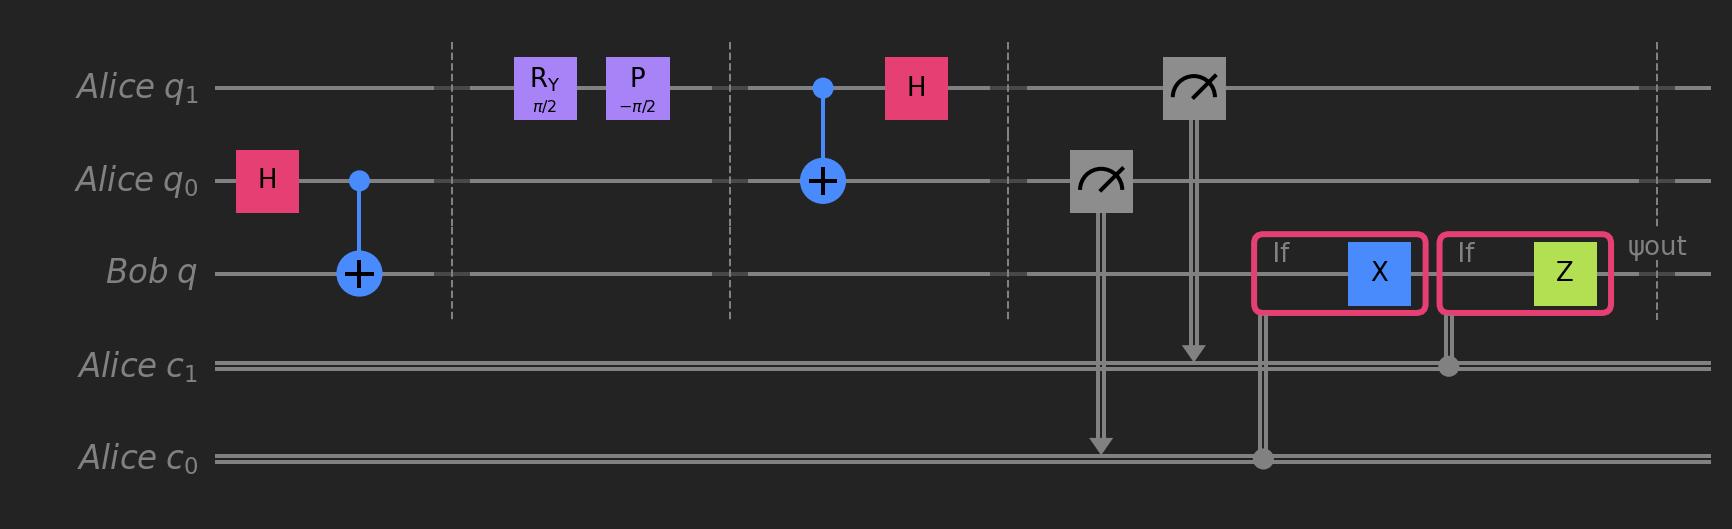

In [2]:
qra = QuantumRegister(2,name="Alice q")
qrb = QuantumRegister(1,name="Bob q")
cra = ClassicalRegister(2, name="Alice c")

qc = QuantumCircuit(qrb,qra,cra)

# Alice and Bob share entangled Bell state
qc.h(qra[0])
qc.cx(qra[0],qrb[0])
qc.barrier()

# Alice prepares state |q⟩ = 1/√2|0⟩ - i/√2|1⟩
qc.ry(np.pi/2,qra[1])
qc.p(-np.pi/2,qra[1])
qc.barrier()

# Alice changes from Bell to Computational basis
qc.cx(qra[1],qra[0])
qc.h(qra[1])
qc.barrier()

# Alice measures her qubits
qc.measure(qra,cra)

# Bob applies X, Z gates conditioned on Alice's results
with qc.if_test((cra[0], 1)): qc.x(0)
with qc.if_test((cra[1], 1)): qc.z(0)

qc.save_statevector('ψout')

qc.draw(cregbundle=False)

In [3]:
simulator = AerSimulator()

# run simulation 5 times
for i in range(5):
    result = simulator.run(qc, shots=1, memory=True).result()
    alices_bits = result.get_memory()[0]
    ψout = result.data().get('ψout')

    ρout = partial_trace(ψout,[1,2])
    bobs_state = DensityMatrix(np.round(ρout, 8)).to_statevector()
    
    print(f'Alice measured qubits (j,i) = ({alices_bits[1]},{alices_bits[0]})\n')
    print('Bob\'s final state:')
    display(bobs_state)

Alice measured qubits (j,i) = (0,1)

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits (j,i) = (0,0)

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits (j,i) = (1,1)

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits (j,i) = (0,1)

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits (j,i) = (0,0)

Bob's final state:


<IPython.core.display.Latex object>

As seen, Bob always manages to obtain the same state once he applies the right correction gates based on Alice's results.

### 2.2 Teleporting Multi-Qubit States

Generalizing quantum teleportation for multi-qubit states is simple. Alice and Bob just need to share a pair of entangled qubits for each qubit in the state they want to teleport.

Let's look at an example using qiskit where Alice wants to teleport the following state to Bob:

$$ |q\rangle = \frac{1}{\sqrt{3}}\big(|001\rangle - |010\rangle + |100\rangle \big).$$

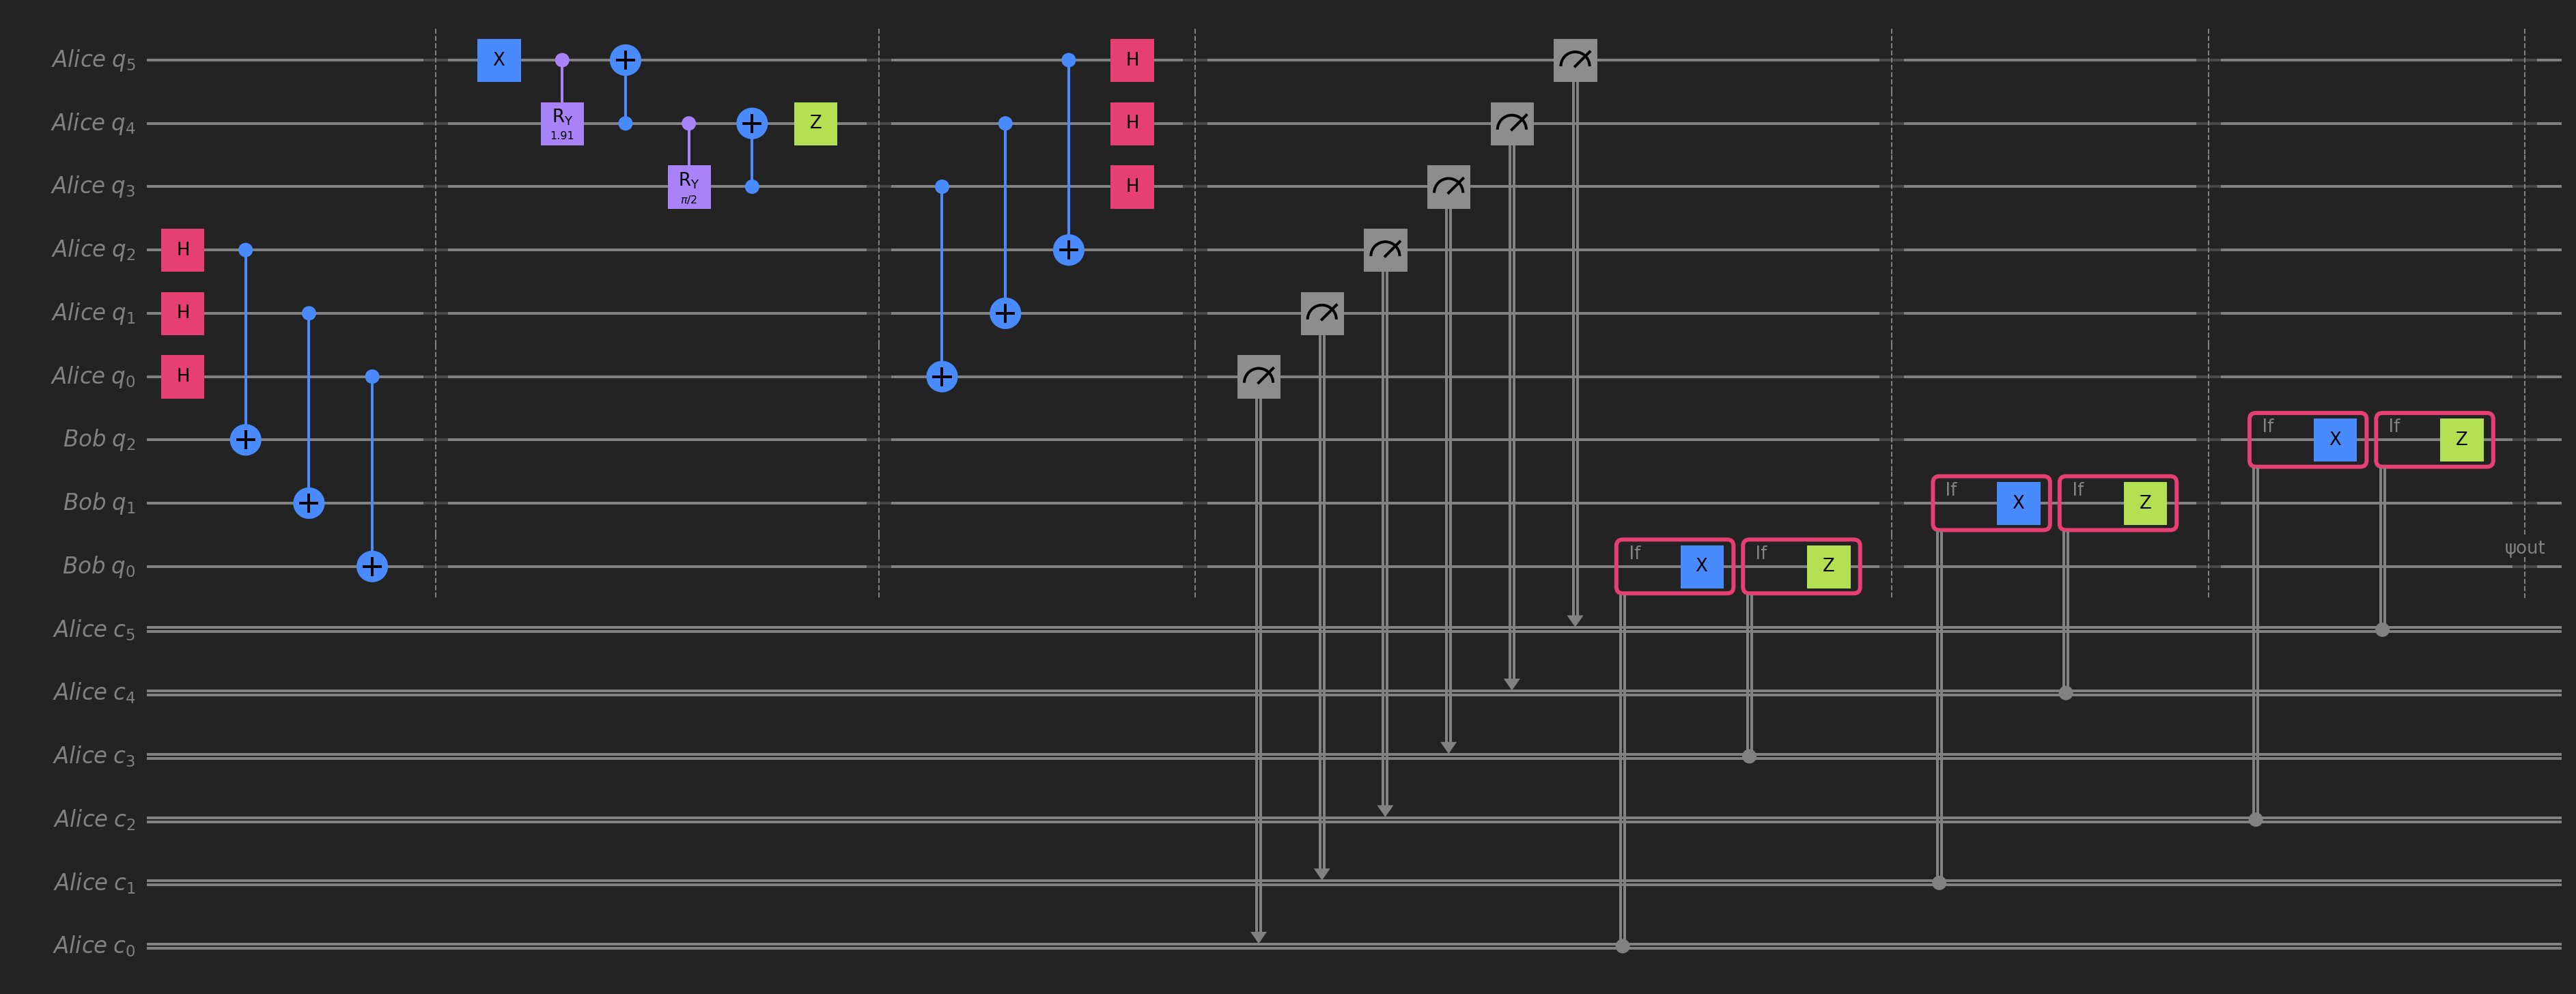

In [4]:
qra = QuantumRegister(6,name="Alice q")
qrb = QuantumRegister(3,name="Bob q")
cra = ClassicalRegister(6, name="Alice c")

qc = QuantumCircuit(qrb,qra,cra)

# Alice and Bob share two entangled Bell states
qc.h([qra[i] for i in range(3)])
qc.cx([qra[i] for i in reversed(range(3))],[qrb[i] for i in reversed(range(3))])
qc.barrier()


# Alice prepares state |w⟩ = 1/2|01⟩ - √3/2|10⟩
qc.x(qra[5])
qc.cry(2*np.arccos(np.sqrt(1/3)),qra[5],qra[4])
qc.cx(qra[4],qra[5])
qc.cry(2*np.arccos(np.sqrt(1/2)),qra[4],qra[3])
qc.cx(qra[3],qra[4])
qc.z(qra[4])
qc.barrier()

# Alice changes from Bell to Computational basis
qc.cx([qra[i] for i in range(3,6)],[qra[i] for i in range(3)])
qc.h([qra[i] for i in range(3,6)])
qc.barrier()

# Alice measures her qubits
qc.measure(qra,cra)

# Bob applies X, Z gates conditioned on Alice's results

for i in range(3):
    with qc.if_test((cra[i], 1)): qc.x(i)
    with qc.if_test((cra[i+3], 1)): qc.z(i)
    if i <2: qc.barrier()

qc.save_statevector('ψout')

qc.draw(cregbundle=False, fold=-1)

In [5]:
simulator = AerSimulator()

# run simulation 5 times
for i in range(5):
    result = simulator.run(qc, shots=1, memory=True).result()
    alices_bits = result.get_memory()[0]
    ψout = result.data().get('ψout')
    ρout = partial_trace(ψout,[i for i in range(3,9)])
    bobs_state = DensityMatrix(np.round(ρout, 8)).to_statevector()
    
    
    print(f'Alice measured qubits = {alices_bits}\n')
    print('Bob\'s final state:')
    display(bobs_state)

Alice measured qubits = 011100

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits = 111100

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits = 011001

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits = 001110

Bob's final state:


<IPython.core.display.Latex object>

Alice measured qubits = 100001

Bob's final state:


<IPython.core.display.Latex object>